# 11.4 — Parameter interactions

**Question.** Do prespecified historical parameter pairs have joint effects beyond additive main effects? The `test` profile validates one 2×2 pair on synthetic cells; screen/full run the config-defined grids with env-resolved features. Exact optimizer counts are printed before execution.

Runs resume from signed artifacts under the legacy sensitivity root. Heatmaps report seed-averaged means and residuals after removing both additive main effects. Residuals are descriptive within the tested grid, not causal interactions, and sparse grids or weak optimizer replication limit interpretation.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from estonia_landuse.sensitivity.analysis import (
    estimate_interaction_surface,
    select_matched_baseline_runs,
    summarize_interaction_noise,
)
from estonia_landuse.sensitivity.config import DEFAULT_SEEDS, INTERACTION_LEVELS
from estonia_landuse.sensitivity.plots import plot_interaction_heatmap
from estonia_landuse.sensitivity.runner import run_manifest
from estonia_landuse.sensitivity.sampling import INTERACTION_PAIRS, build_interaction_manifest, manifest_run_count, manifest_summary

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
HISTORICAL_ROOT = PROJECT_ROOT.parent.parent if PROJECT_ROOT.parent.name == ".worktrees" else PROJECT_ROOT
# PROFILE = os.environ.get("SENSITIVITY_PROFILE", "test")
PROFILE = os.environ.get("SENSITIVITY_PROFILE", "full")
N_WORKERS = int(os.environ.get("SENSITIVITY_N_WORKERS", "12"))
OVERWRITE = os.environ.get("SENSITIVITY_OVERWRITE", "false").lower() == "true"
OUTPUT_ROOT = Path(os.environ.get("SENSITIVITY_OUTPUT_ROOT", PROJECT_ROOT / "data/processed/legacy_sensitivity")).resolve()
FEATURES_PATH = Path(os.environ.get("SENSITIVITY_FEATURES_PATH", HISTORICAL_ROOT / "data/processed/learned_carbon/features_with_forest.parquet")).resolve()
SEEDS = (0, 1) if PROFILE == "test" else DEFAULT_SEEDS[PROFILE]
SCENARIOS = ("balanced",)
# PAIRS = INTERACTION_PAIRS[:1] if PROFILE == "test" else INTERACTION_PAIRS
#NB! take only half the pairs to  save time!!
PAIRS = INTERACTION_PAIRS[:1] if PROFILE == "test" else INTERACTION_PAIRS[:2]
LEVELS = INTERACTION_LEVELS[PROFILE]
OUTCOMES = ("biodiversity_gain", "carbon_gain", "cost", "changed_pct")


In [2]:
if PROFILE == "test":
    position = np.linspace(0.0, 1.0, 12)
    context = pd.DataFrame({"cell_id": np.arange(1, 13), "forest_pct": 0.35 + 0.03 * position, "wetland_pct": 0.10 + 0.02 * position, "agriculture_pct": 0.30 - 0.03 * position, "grassland_pct": 0.15 - 0.02 * position, "urban_pct": np.full(12, 0.05), "water_pct": np.full(12, 0.05), "protected_overlap_pct": 0.05 * position, "wetland_suitability": 0.2 + 0.6 * position, "opportunity_cost_proxy": 0.1 + 0.5 * position, "predicted_tco2_ha_yr": 2.5 + 2.0 * position, "peat_overlap_pct": 0.4 * position})
    feature_columns = ["wetland_suitability", "opportunity_cost_proxy"]
else:
    if not FEATURES_PATH.exists(): raise FileNotFoundError(f"Missing historical feature input: {FEATURES_PATH}")
    context = pd.read_parquet(FEATURES_PATH)
    feature_columns = [name for name in ("urban_pct", "agriculture_pct", "grassland_pct", "forest_pct", "wetland_pct", "water_pct", "naturalness_score", "carbon_score", "protected_overlap_pct", "wetland_suitability", "biodiversity_proxy", "opportunity_cost_proxy", "rohemeeter_norm") if name in context]
    if not feature_columns: raise ValueError("No preserved Notebook 10 feature columns found")


In [3]:
manifests = [build_interaction_manifest(profile=PROFILE, pair=pair, levels=LEVELS, scenarios=SCENARIOS, seeds=SEEDS) for pair in PAIRS]
manifest = pd.concat(manifests, ignore_index=True)
planned_runs = manifest_run_count(manifest)
manifest_summary(manifest)
display(manifest.head(6))


interactions: 150 optimizer runs (profile=full)


,experiment,sample_id,scenario,seed,profile,parameter_x,parameter_y,value_x,value_y,overrides,status
0,interactions,interactions__scoring_base_change_cost__max_ch...,balanced,42,full,scoring.base_change_cost,max_changed_pct,0.0,0.0500,"{'scoring.base_change_cost': 0.0, 'max_changed...",pending
1,interactions,interactions__scoring_base_change_cost__max_ch...,balanced,73,full,scoring.base_change_cost,max_changed_pct,0.0,0.0500,"{'scoring.base_change_cost': 0.0, 'max_changed...",pending
2,interactions,interactions__scoring_base_change_cost__max_ch...,balanced,101,full,scoring.base_change_cost,max_changed_pct,0.0,0.0500,"{'scoring.base_change_cost': 0.0, 'max_changed...",pending
3,interactions,interactions__scoring_base_change_cost__max_ch...,balanced,42,full,scoring.base_change_cost,max_changed_pct,0.0,0.1125,"{'scoring.base_change_cost': 0.0, 'max_changed...",pending
4,interactions,interactions__scoring_base_change_cost__max_ch...,balanced,73,full,scoring.base_change_cost,max_changed_pct,0.0,0.1125,"{'scoring.base_change_cost': 0.0, 'max_changed...",pending
5,interactions,interactions__scoring_base_change_cost__max_ch...,balanced,101,full,scoring.base_change_cost,max_changed_pct,0.0,0.1125,"{'scoring.base_change_cost': 0.0, 'max_changed...",pending


In [4]:
statuses = run_manifest(context, feature_columns, manifest, OUTPUT_ROOT, PROFILE, overwrite=OVERWRITE, n_workers=min(N_WORKERS, planned_runs), progress=lambda completed, total, status: print(f"[{completed}/{total}] {status}"))
if statuses["status"].eq("failed").any(): raise RuntimeError(statuses.loc[statuses["status"].eq("failed"), ["sample_id", "seed", "error_message"]].to_string(index=False))
assert len(statuses) == planned_runs
display(statuses["status"].value_counts())


[1/150] completed
[2/150] completed
[3/150] completed
[4/150] completed
[5/150] completed
[6/150] completed
[7/150] completed
[8/150] completed
[9/150] completed
[10/150] completed
[11/150] completed
[12/150] completed
[13/150] completed
[14/150] completed
[15/150] completed
[16/150] completed
[17/150] completed
[18/150] completed
[19/150] completed
[20/150] completed
[21/150] completed
[22/150] completed
[23/150] completed
[24/150] completed
[25/150] completed
[26/150] completed
[27/150] completed
[28/150] completed
[29/150] completed
[30/150] completed
[31/150] completed
[32/150] completed
[33/150] completed
[34/150] completed
[35/150] completed
[36/150] completed
[37/150] completed
[38/150] completed
[39/150] completed
[40/150] completed
[41/150] completed
[42/150] completed
[43/150] completed
[44/150] completed
[45/150] completed
[46/150] completed
[47/150] completed
[48/150] completed
[49/150] completed
[50/150] completed
[51/150] completed
[52/150] completed
[53/150] completed
[5

status
completed    150
Name: count, dtype: int64

,scenario,parameter_x,parameter_y,outcome,max_abs_interaction_residual,rms_interaction_residual,baseline_sd,max_abs_residual_to_noise,rms_residual_to_noise
4,balanced,scoring.agriculture_loss_cost,scoring.max_agriculture_loss_pct,biodiversity_gain,0.003011,0.001001,0.000783,3.844823,1.278485
6,balanced,scoring.agriculture_loss_cost,scoring.max_agriculture_loss_pct,cost,0.030483,0.013881,0.013346,2.284123,1.040129
0,balanced,scoring.base_change_cost,max_changed_pct,biodiversity_gain,0.001421,0.000789,0.000783,1.814441,1.007498
2,balanced,scoring.base_change_cost,max_changed_pct,cost,0.017534,0.008110,0.013346,1.313837,0.607701
5,balanced,scoring.agriculture_loss_cost,scoring.max_agriculture_loss_pct,carbon_gain,0.003454,0.001605,0.003084,1.119968,0.520298
7,balanced,scoring.agriculture_loss_cost,scoring.max_agriculture_loss_pct,changed_pct,0.008294,0.003781,0.007521,1.102767,0.502753
1,balanced,scoring.base_change_cost,max_changed_pct,carbon_gain,0.002563,0.001239,0.003084,0.831255,0.401854
3,balanced,scoring.base_change_cost,max_changed_pct,changed_pct,0.005237,0.002199,0.007521,0.696346,0.292442


,x,y,mean,sd,n_seeds,interaction_residual
0,0.00,0.0500,0.007346,0.001347,3,0.000931
1,0.00,0.1125,0.008810,0.002086,3,-0.001291
2,0.00,0.1750,0.009922,0.001107,3,-0.001094
3,0.00,0.2375,0.012016,0.001778,3,0.001421
4,0.00,0.3000,0.011739,0.001328,3,0.000034
5,0.25,0.0500,0.006214,0.000252,3,-0.000290
6,0.25,0.1125,0.008907,0.000933,3,-0.001281
7,0.25,0.1750,0.012488,0.000852,3,0.001384
8,0.25,0.2375,0.010580,0.001717,3,-0.000102
9,0.25,0.3000,0.012081,0.001944,3,0.000289


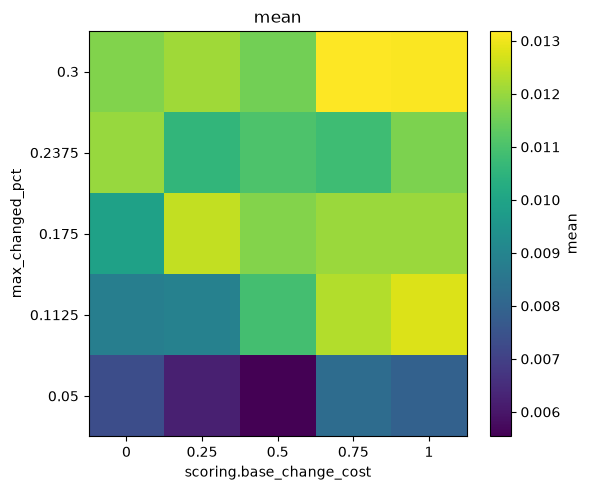

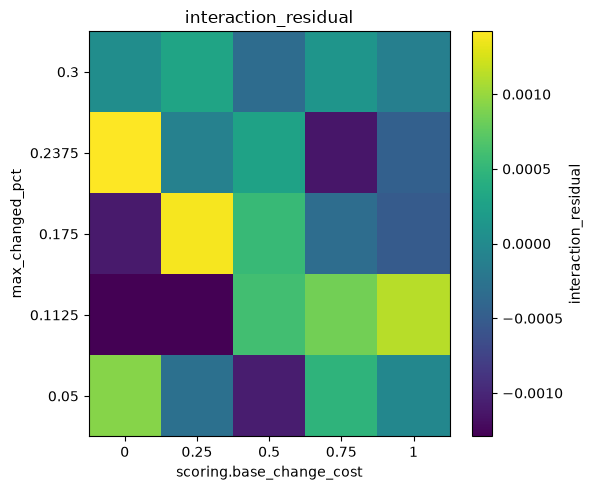

,x,y,mean,sd,n_seeds,interaction_residual
0,0.00,0.0500,0.008831,0.001502,3,0.000186
1,0.00,0.1125,0.016764,0.002500,3,-0.002407
2,0.00,0.1750,0.020268,0.002044,3,0.001005
3,0.00,0.2375,0.020660,0.003891,3,0.002324
4,0.00,0.3000,0.019363,0.005496,3,-0.001107
5,0.25,0.0500,0.009866,0.000983,3,0.000331
6,0.25,0.1125,0.019130,0.002380,3,-0.000930
7,0.25,0.1750,0.019854,0.002267,3,-0.000299
8,0.25,0.2375,0.017561,0.001314,3,-0.001665
9,0.25,0.3000,0.023923,0.000364,3,0.002563


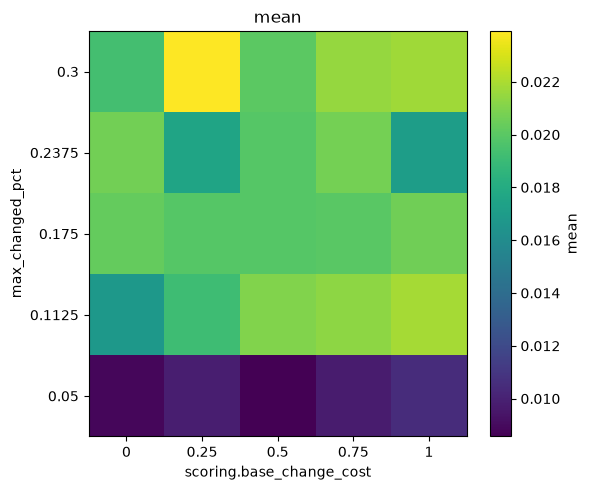

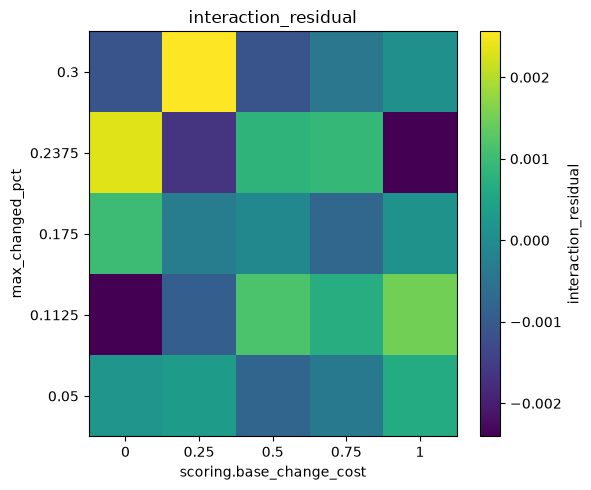

,x,y,mean,sd,n_seeds,interaction_residual
0,0.00,0.0500,0.080384,0.016491,3,0.006822
1,0.00,0.1125,0.098690,0.046054,3,-0.011347
2,0.00,0.1750,0.100716,0.030073,3,-0.014629
3,0.00,0.2375,0.126185,0.039181,3,0.017534
4,0.00,0.3000,0.117136,0.022858,3,0.001620
5,0.25,0.0500,0.073286,0.016957,3,-0.000708
6,0.25,0.1125,0.104608,0.014269,3,-0.005861
7,0.25,0.1750,0.112139,0.015359,3,-0.003637
8,0.25,0.2375,0.103482,0.024120,3,-0.005602
9,0.25,0.3000,0.131755,0.005344,3,0.015807


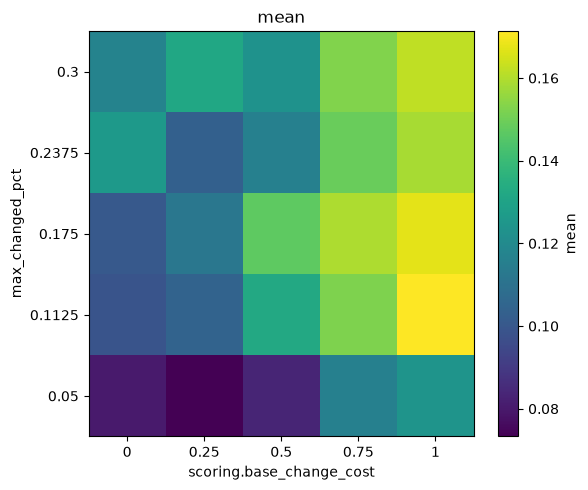

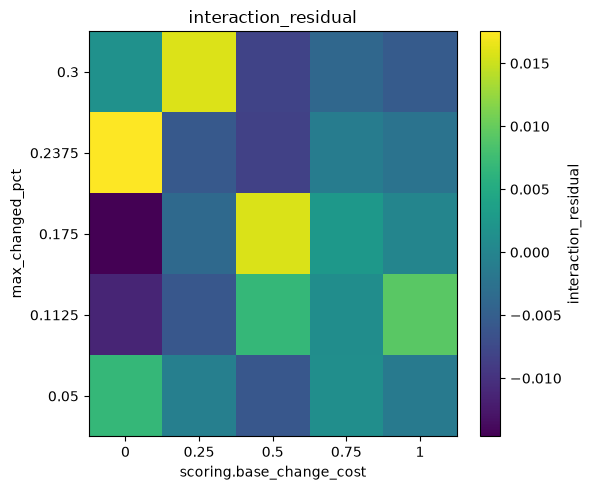

,x,y,mean,sd,n_seeds,interaction_residual
0,0.00,0.0500,0.033145,0.002178,3,-0.001291
1,0.00,0.1125,0.059242,0.003904,3,-0.001002
2,0.00,0.1750,0.062923,0.003523,3,0.000895
3,0.00,0.2375,0.063325,0.009643,3,0.003223
4,0.00,0.3000,0.063847,0.011314,3,-0.001824
5,0.25,0.0500,0.035586,0.001295,3,0.000813
6,0.25,0.1125,0.055705,0.004212,3,-0.004876
7,0.25,0.1750,0.063052,0.004088,3,0.000687
8,0.25,0.2375,0.059897,0.005836,3,-0.000541
9,0.25,0.3000,0.069926,0.002846,3,0.003918


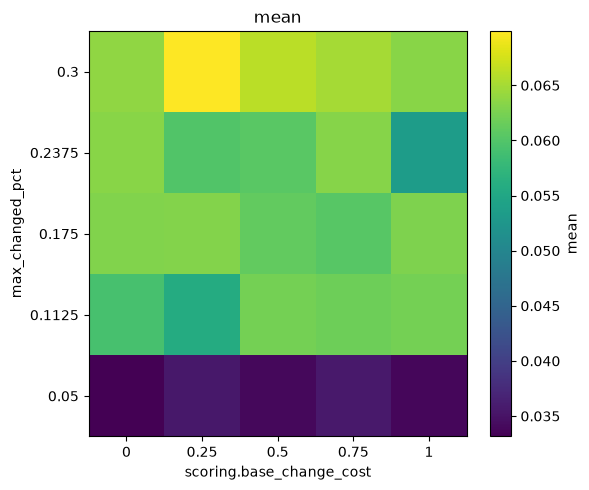

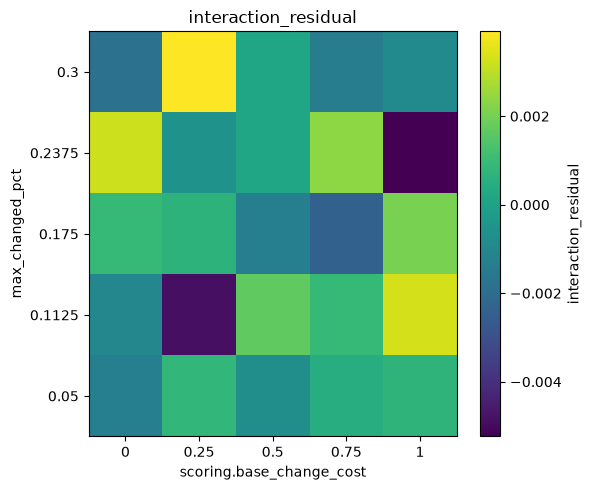

,x,y,mean,sd,n_seeds,interaction_residual
0,0.0,0.0500,0.006401,0.001439,3,-0.003011
1,0.0,0.1625,0.011400,0.001363,3,0.000721
2,0.0,0.2750,0.012685,0.001131,3,0.000896
3,0.0,0.3875,0.012907,0.001755,3,0.000444
4,0.0,0.5000,0.013467,0.000758,3,0.000950
5,2.5,0.0500,0.007751,0.002249,3,-0.000121
6,2.5,0.1625,0.008206,0.000474,3,-0.000932
7,2.5,0.2750,0.010105,0.001040,3,-0.000144
8,2.5,0.3875,0.011648,0.002462,3,0.000725
9,2.5,0.5000,0.011448,0.001485,3,0.000472


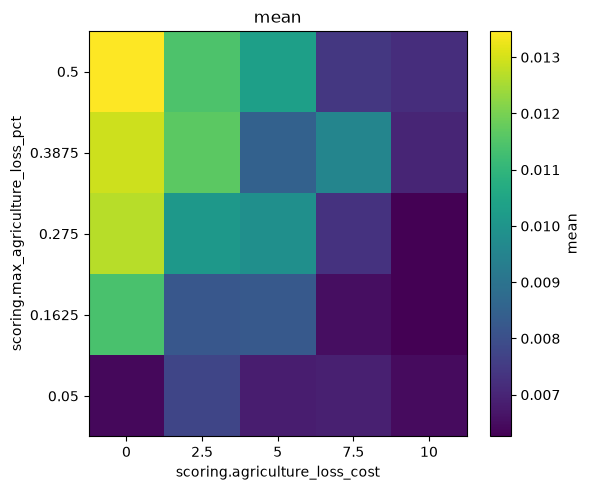

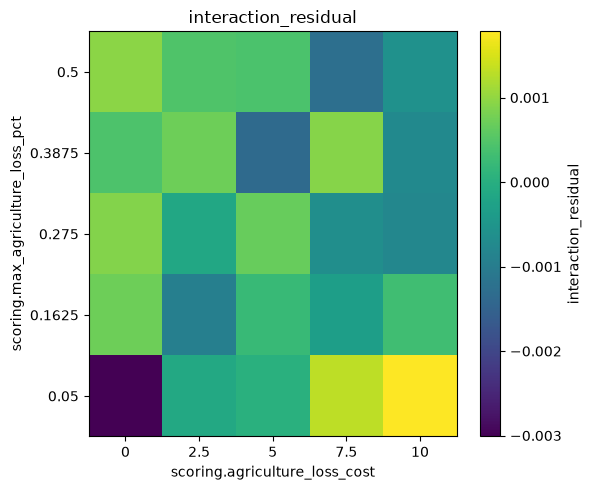

,x,y,mean,sd,n_seeds,interaction_residual
0,0.0,0.0500,0.016185,0.002817,3,-0.003009
1,0.0,0.1625,0.021108,0.004904,3,0.001534
2,0.0,0.2750,0.018704,0.002069,3,-0.002043
3,0.0,0.3875,0.022302,0.004290,3,0.002069
4,0.0,0.5000,0.022266,0.001381,3,0.001448
5,2.5,0.0500,0.017812,0.005487,3,-0.001201
6,2.5,0.1625,0.018239,0.002458,3,-0.001153
7,2.5,0.2750,0.020828,0.003983,3,0.000262
8,2.5,0.3875,0.019547,0.001757,3,-0.000505
9,2.5,0.5000,0.023233,0.003790,3,0.002596


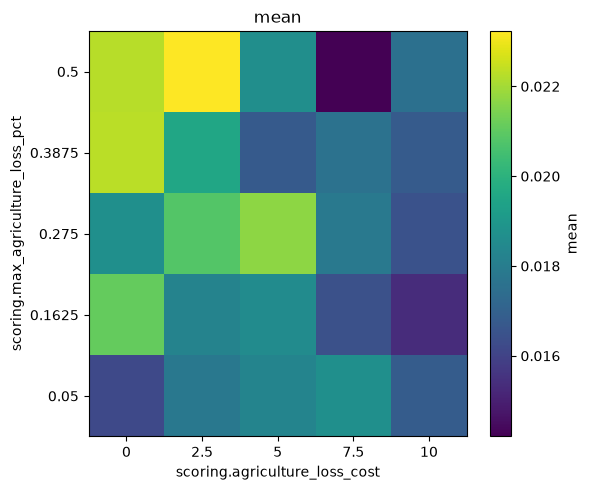

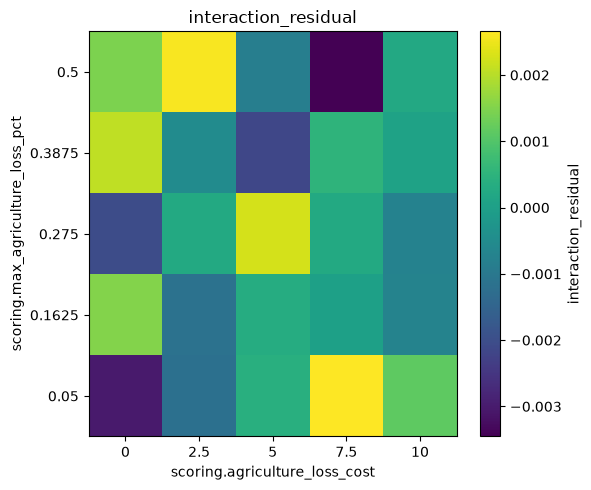

,x,y,mean,sd,n_seeds,interaction_residual
0,0.0,0.0500,0.192373,0.016705,3,-0.024569
1,0.0,0.1625,0.154521,0.013617,3,0.030483
2,0.0,0.2750,0.093888,0.009133,3,0.009513
3,0.0,0.3875,0.078647,0.023549,3,-0.003526
4,0.0,0.5000,0.051455,0.004748,3,-0.011900
5,2.5,0.0500,0.281859,0.041919,3,0.022545
6,2.5,0.1625,0.152164,0.030872,3,-0.014245
7,2.5,0.2750,0.121226,0.023749,3,-0.005519
8,2.5,0.3875,0.125750,0.017833,3,0.001205
9,2.5,0.5000,0.101742,0.011511,3,-0.003985


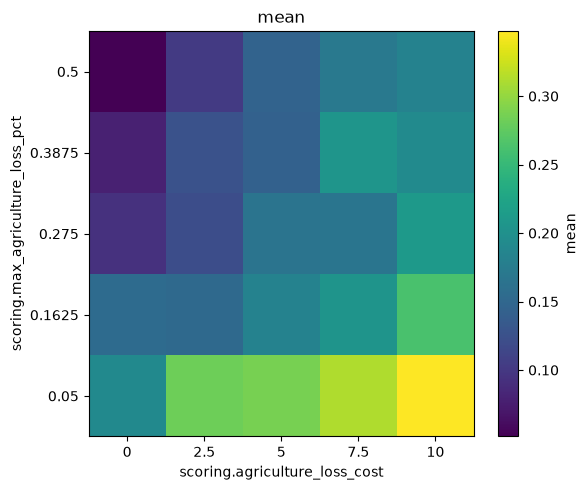

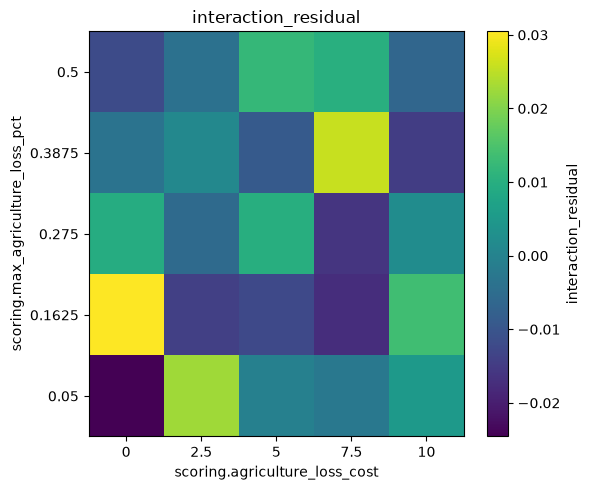

,x,y,mean,sd,n_seeds,interaction_residual
0,0.0,0.0500,0.051760,0.004134,3,-0.008294
1,0.0,0.1625,0.059695,0.008884,3,0.000464
2,0.0,0.2750,0.061101,0.001850,3,-0.002645
3,0.0,0.3875,0.064884,0.006960,3,0.004432
4,0.0,0.5000,0.068544,0.003444,3,0.006043
5,2.5,0.0500,0.056617,0.008400,3,-0.003170
6,2.5,0.1625,0.058759,0.005367,3,-0.000205
7,2.5,0.2750,0.063102,0.008011,3,-0.000378
8,2.5,0.3875,0.059098,0.002555,3,-0.001087
9,2.5,0.5000,0.067074,0.007142,3,0.004841


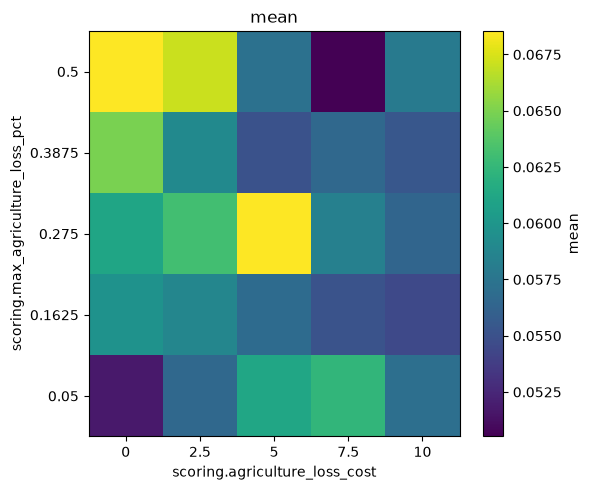

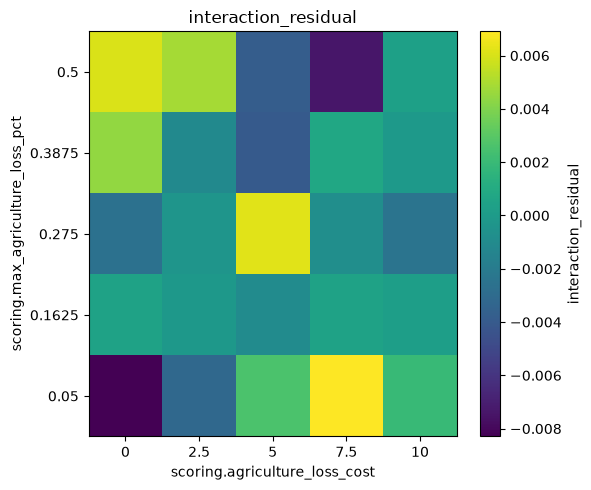

In [5]:
metrics = pd.concat([pd.read_parquet(path) for path in statuses["metrics_path"]], ignore_index=True)
baseline_paths = sorted((OUTPUT_ROOT / "runs" / "baseline").rglob("seed_*.parquet"))
if not baseline_paths: raise FileNotFoundError("Run Notebook 11.1 with this SENSITIVITY_OUTPUT_ROOT first")
baseline_candidates = pd.concat([pd.read_parquet(path) for path in baseline_paths], ignore_index=True)
baseline = select_matched_baseline_runs(
    baseline_candidates, metrics, expected_scenarios=SCENARIOS, expected_seeds=SEEDS
)
interaction_noise = summarize_interaction_noise(metrics, baseline, OUTCOMES)
display(interaction_noise.sort_values("max_abs_residual_to_noise", ascending=False)[[
    "scenario", "parameter_x", "parameter_y", "outcome",
    "max_abs_interaction_residual", "rms_interaction_residual", "baseline_sd",
    "max_abs_residual_to_noise", "rms_residual_to_noise",
]])
for parameter_x, parameter_y in PAIRS:
    pair_metrics = metrics.loc[metrics["parameter_x"].eq(parameter_x) & metrics["parameter_y"].eq(parameter_y)]
    for outcome in OUTCOMES:
        surface = estimate_interaction_surface(pair_metrics, outcome)
        display(surface)
        for value_column in ("mean", "interaction_residual"):
            figure, _ = plot_interaction_heatmap(surface, value_column, parameter_x, parameter_y)
            display(figure)
            plt.close(figure)
